<a href="https://colab.research.google.com/github/hadasecohen/streaming-vae-anomaly-detection/blob/main/notebooks/cases/case03_threshold_calibration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case 3

# How does the prediction threshold affect LSTM-VAE detection of group anomalies?

## Purpose of this notebook

This notebook demonstrates a scenario that was observed in one of the exploration areas the thesis:

> The focus of the experiment is how the prediction threshold controls the trade-off between false alarms and missed anomalies — a lower threshold flags more anomalies (higher recall, more false positives), a higher threshold requires stronger evidence before predicting an anomaly (higher precision, more missed anomalies).

The thesis studies anomaly detection in streaming ERA5 weather data. It compares the impact of different configurations (VAE architecture, streaming and feature manipulation methods, decision threshold) on VAEs with different deep learning models as encoder/decoder.

This testcase focuses on **group anomalies** (collective mean-shift blocks) and a single architecture, **LSTM-VAE**, evaluated at four prediction thresholds.

---

For the complete experiment definitions, consult the thesis section associated with **4.3.1 Effect of Prediction Threshold Choice**, together with the YAML configuration files used by this suite.

## What is being compared?

The notebook runs four LSTM-VAE variants, identical except for the decision threshold applied to the anomaly score:

| Variant | Prediction threshold | Meaning |
|---|---:|---|
| **LSTM-VAE** | 0.70 | Lowest threshold tested — most permissive, flags anomalies most readily. |
| **LSTM-VAE** | 0.80 | |
| **LSTM-VAE** | 0.90 | |
| **LSTM-VAE** | 0.95 | Highest threshold tested — most conservative, requires the strongest evidence before predicting an anomaly. |

An observation is predicted anomalous when its anomaly score exceeds the threshold (`training.anom_if_score_above`).

## Findings being illustrated

The thesis found that raising the prediction threshold trades recall for precision: as the threshold rises, fewer normal observations are misclassified as anomalies (precision increases), but true anomalies whose scores fall below the new, higher bar are increasingly missed (recall decreases). This is not just a static trade-off — the thesis also observed **when** in the stream that trade-off shows up: a low threshold tends to over-predict anomalies early in the stream, before the adaptive score calibration stabilises, while a high threshold's recall loss can be concentrated in specific stretches of the stream rather than spread evenly.

This reduced notebook uses the full-scale ERA5 export by default (see `case01_clean_baseline.ipynb` for why), so results should be directionally close to the thesis, though exact metric values are not expected to match (single seed, this repo's own port of the training code). The important result is the **relative pattern across the four thresholds**.

---

## What this notebook will do

1. Check whether a GPU is available.
2. Clone and install the thesis repository.
3. Run the four threshold variants on the same group-anomaly dataset.
4. Collect F1, AUC, precision, recall, and confusion-matrix counts.
5. Display plots that compare threshold behaviour, including how it changes across the stream.

### Expected runtime

Window-based runs use the GPU when available. All four variants share the same architecture (LSTM-VAE) and dataset, so runtimes should be similar across variants.

# Run Case

### Check GPU availability

In [1]:
%matplotlib inline
import torch

print("Environment check")
print("-----------------")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Selected device:", torch.cuda.get_device_name(0))
else:
    print(
        "No GPU was detected. The notebook can still run, but "
        "window-based training may be slower."
    )


Environment check
-----------------
PyTorch version: 2.11.0+cu128
CUDA available: True
Selected device: Tesla T4


### Import and/or load Repo

In [2]:
import os
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/hadasecohen/streaming-vae-anomaly-detection.git"
REPO_DIR = Path("/content/repo") if "COLAB_RELEASE_TAG" in os.environ else Path("repo")

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not REPO_DIR.exists():
        subprocess.run(
            ["git", "clone", REPO_URL, str(REPO_DIR)],
            check=True,
        )

    os.chdir(REPO_DIR)
else:
    # When launched from notebooks/cases inside a local checkout,
    # move to the repository root.
    if not Path("scripts/run_all_trials.py").exists():
        os.chdir("../..")

print("Working directory:", os.getcwd())
print("Installing the project dependencies...")
subprocess.run(
    ["python", "-m", "pip", "install", "-q", "-r", "requirements.txt"],
    check=True,
)
%env MPLBACKEND=Agg
print("Setup complete.")


Working directory: /content/repo
Installing the project dependencies...
env: MPLBACKEND=Agg
Setup complete.


### Step 1 — Configure the run

In [3]:
import os
import yaml

CASE_ID = "case03_threshold_calibration"
SESSION_DIR = "runs/trials_suite"
OUTPUT_DIR = f"{SESSION_DIR}/{CASE_ID}"

# Edit this directly — works the same locally and on Colab:
#   "full_split_files" (default) -> anom_types/group.yaml's own default —
#                      full-scale group-anomaly data, pre-split into a
#                      warmup-only file (shared with case01 — the warmup
#                      portion is anomaly-free and identical regardless of
#                      anomaly type) and a test-only file with the
#                      group anomalies injected. Committed to the repo.
#   "mini_50pct"    -> the in-repo 377,784-row ERA5 slice (~50% of full-scale).
#                      Committed to the repo.
#   "mini_28pct"    -> the in-repo 210,384-row ERA5 slice (~28% of full-scale).
#                      Committed to the repo.
DATA_SOURCE = "full_split_files"

_DATA_SOURCE_LAYERS = {
    "full_split_files": None,   # anom_types/group.yaml's own default — no extra layer needed
    "mini_50pct": "../../modules/data_source/mini_50pct_group.yaml",
    "mini_28pct": "../../modules/data_source/mini_28pct_group.yaml",
}

_suite_source_path = f"notebooks/cases/{CASE_ID}_suite.yaml"
_suite_dir = os.path.dirname(os.path.abspath(_suite_source_path))

def _resolve(path):
    # base_config / config_layers entries are relative paths meant to be
    # read relative to the suite file's own directory (notebooks/cases/).
    # Resolving them to absolute paths here — rather than leaving them
    # relative — means the resolved copy stays correct no matter how deep
    # under OUTPUT_DIR it ends up being written.
    return path if os.path.isabs(path) else os.path.normpath(os.path.join(_suite_dir, path))

_data_source_layer = _DATA_SOURCE_LAYERS[DATA_SOURCE]

with open(_suite_source_path) as f:
    _suite = yaml.safe_load(f)

_suite["base_config"] = _resolve(_suite["base_config"])
for _run in _suite["runs"]:
    _layers = [_resolve(p) for p in _run["config_layers"]]
    if _data_source_layer:
        _layers.append(_resolve(_data_source_layer))
    _run["config_layers"] = _layers

# Written under OUTPUT_DIR (runs/, already gitignored and read-write) rather
# than notebooks/ (source-controlled, meant to stay read-only) — os.makedirs
# because OUTPUT_DIR won't exist yet on a fresh run.
os.makedirs(OUTPUT_DIR, exist_ok=True)
SUITE_PATH = f"{OUTPUT_DIR}/{CASE_ID}_suite_resolved.yaml"
with open(SUITE_PATH, "w") as f:
    yaml.safe_dump(_suite, f, sort_keys=False)

print(f"DATA_SOURCE = {DATA_SOURCE!r} -> {_data_source_layer}")

DATA_SOURCE = 'full_split_files' -> None


#### Configuration file

The notebooks test suites combines a shared ERA5 configuration (`modules/era5_common.yaml`) with the architecture, anomaly type, stream mode, and threshold settings for each run.

`DATA_SOURCE` may be configured to choose other datasets from the era5 data directory.
The default is `"full_split_files"`, which is the full-scale group-anomaly data, where warmup and test files are split (`data/era5/full_scale/split/era5_clean_warmup.csv` and `data/era5/full_scale/split/era5_group_test.csv`).

All variants use the same base configuration, architecture, and evaluation procedure. The intended comparison is therefore the effect of **the prediction threshold** on LSTM-VAE's group-anomaly detection.

#### Output Directory

During execution, the script creates a separate run directory in the repo for each variant under `OUTPUT_DIR` (`runs/trials_suite/case03_threshold_calibration` by default).

`notebooks/cases/case03_threshold_calibration_suite.yaml` layers `modules/era5_common.yaml` with the architecture / anomaly-type / stream-mode fragments and the per-run threshold override (see the suite file for the exact overrides).

### Step 2 Run the testsuite

### Command:

**If this fails with `ModuleNotFoundError: No module named 'src.utils'`**, please [open a GitHub issue](https://github.com/hadasecohen/streaming-vae-anomaly-detection/issues/new) with the full traceback rather than trying to fix it locally — it means the compiled `src/` no longer matches Colab's Python version and needs to be recompiled and re-released.

In [4]:
!python scripts/run_all_trials.py {SUITE_PATH} \
    --session {SESSION_DIR} --skip-existing

[suite] log     : /content/repo/runs/trials_suite/suite.log
[suite] suite   : /content/repo/runs/trials_suite/case03_threshold_calibration/case03_threshold_calibration_suite_resolved.yaml
[suite] session : /content/repo/runs/trials_suite
[suite] base cfg: /content/repo/modules/era5_common.yaml
[suite] module  : scripts.trial.run_trial
[suite] GPUs    : [0]  (1 slot(s))
[suite] 4 run(s) planned:
  [  1] LSTM_threshold_0_7  [case03_threshold_calibration/case03_threshold_calibration_suite_resolved]  (module: scripts.trial.run_trial)
  [  2] LSTM_threshold_0_8  [case03_threshold_calibration/case03_threshold_calibration_suite_resolved]  (module: scripts.trial.run_trial)
  [  3] LSTM_threshold_0_9  [case03_threshold_calibration/case03_threshold_calibration_suite_resolved]  (module: scripts.trial.run_trial)
  [  4] LSTM_threshold_0_95  [case03_threshold_calibration/case03_threshold_calibration_suite_resolved]  (module: scripts.trial.run_trial)
[suite] --skip-existing: completed runs will be s

### Step 3 — Build a common comparison

#### The next command reads the predictions from every run and produces:

- a common performance table
- anomaly-score histograms
- an F1 comparison across variants
- confusion-matrix summaries
- seed-stability diagnostics, where applicable.

These outputs are saved under `OUTPUT_DIR/cross_compare/`.

### Command:

In [5]:
!python scripts/cross_compare.py {OUTPUT_DIR}

[cross] session : runs/trials_suite/case03_threshold_calibration
[cross] output  : runs/trials_suite/case03_threshold_calibration/cross_compare
[cross] 4 run(s) found:
  LSTM_Group_0.7                                      arch=LSTM  anomaly=Group  cyclic=False  mode=window
  LSTM_Group_0.8                                      arch=LSTM  anomaly=Group  cyclic=False  mode=window
  LSTM_Group_0.9                                      arch=LSTM  anomaly=Group  cyclic=False  mode=window
  LSTM_Group_0.95                                     arch=LSTM  anomaly=Group  cyclic=False  mode=window

[cross] Loading run data ...
  LSTM_Group_0.7 ... ok
  LSTM_Group_0.8 ... ok
  LSTM_Group_0.9 ... ok
  LSTM_Group_0.95 ... ok

[cross] Writing outputs ...
  saved performance_table.csv
  saved performance_summary.txt

  ══ Group anomalies ═══════════════════════════════════════════════════════════════════════════════════════════════
  run_name                                     arch       variant       

### Step 4 — Quantitative Results

### Command:

In [6]:
import pandas as pd
from IPython.display import display

performance_path = f"{OUTPUT_DIR}/cross_compare/performance_table.csv"
perf = pd.read_csv(performance_path)

columns = [
    "run_name", "arch", "anomaly", "variant",
    "f1", "auc", "precision", "recall",
    "tp", "fp", "fn",
]

print("Comparison of prediction-threshold variants")
display(
    perf[columns]
    .sort_values("variant")
    .reset_index(drop=True)
    .style.format({
        "f1": "{:.3f}",
        "auc": "{:.3f}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
    })
)

Comparison of prediction-threshold variants


,run_name,arch,anomaly,variant,f1,auc,precision,recall,tp,fp,fn
0,LSTM_Group_0.7,LSTM,Group,0.700000,0.648,0.902,0.489,0.963,3783,3956,147
1,LSTM_Group_0.8,LSTM,Group,0.800000,0.732,0.930,0.595,0.950,3733,2539,197
2,LSTM_Group_0.9,LSTM,Group,0.900000,0.821,0.951,0.791,0.853,3354,885,576
3,LSTM_Group_0.95,LSTM,Group,0.950000,0.739,0.940,0.902,0.625,2457,266,1473


#### Focus first on `f1`, `precision`, and `recall`. These are the main thesis metrics:

- **precision** decreases when many normal observations are incorrectly flagged as anomalies (more false positives) — expected to rise as the threshold rises;
- **recall** decreases when true anomalies are missed — expected to fall as the threshold rises;
- `tp`, `fp`, and `fn` show the corresponding counts.

#### Expected pattern

```text
precision:  0.70  <  0.80  <  0.90  <  0.95     (rising with threshold)
recall:     0.70  >  0.80  >  0.90  >  0.95     (falling with threshold)
```

The testcase is successful when precision rises and recall falls monotonically (or close to it) across the four thresholds, even if the exact values differ from the thesis.

This notebook uses only LSTM-VAE, which has the widest run-to-run variance of the four architectures (see `case01_clean_baseline.ipynb`) — a single seed's result may not show this pattern clearly.

### Step 5 — Qualitative support (Plots)

#### F1 / precision / recall vs. threshold

##### Command:

F1 vs threshold:


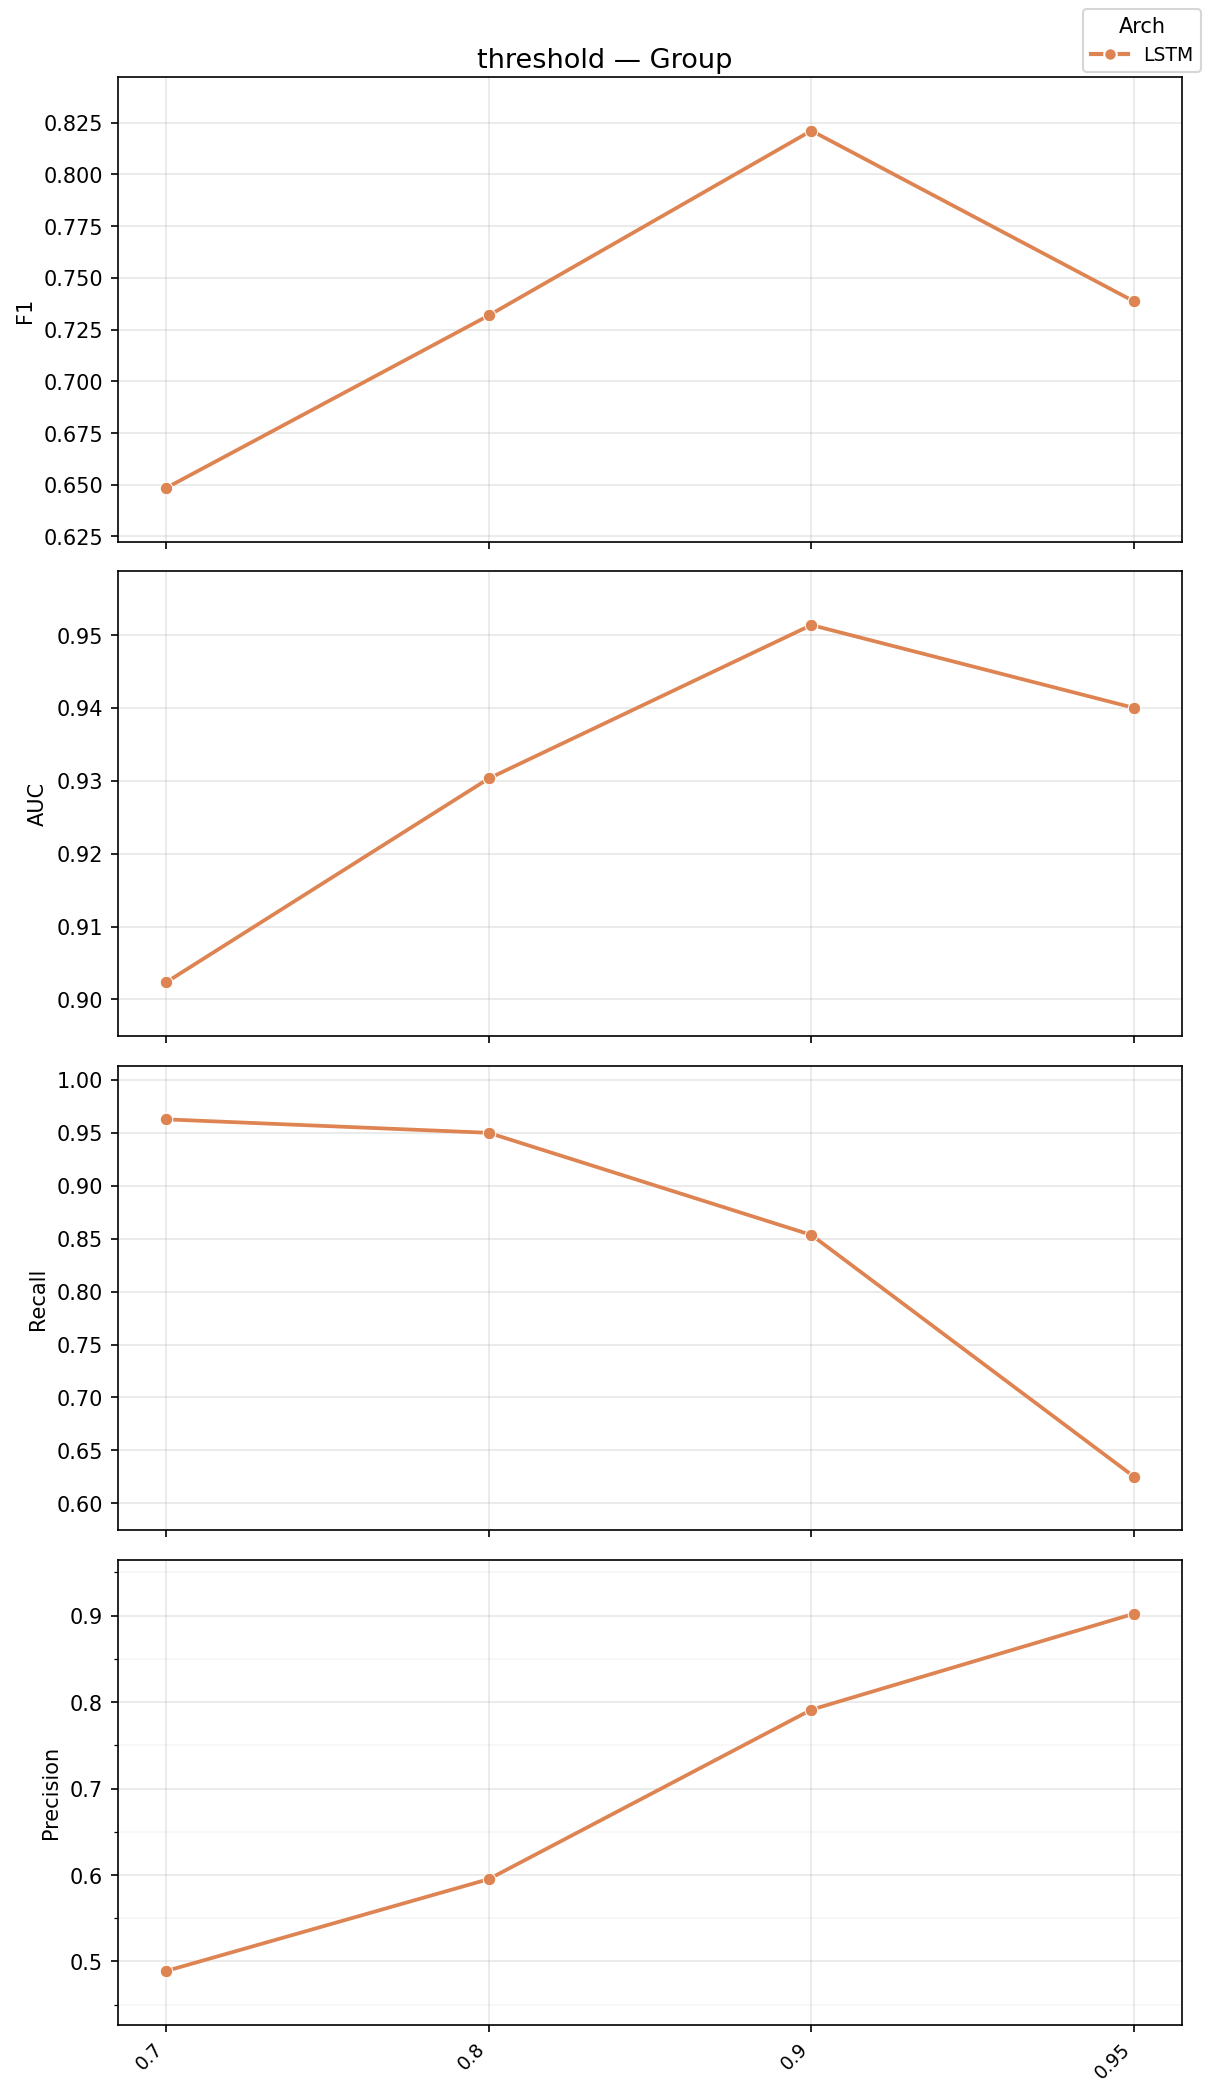

In [7]:
# Display the key comparison plot(s) inline
import glob
from IPython.display import Image, display

print("F1 vs threshold:")
for p in sorted(glob.glob(f"{OUTPUT_DIR}/cross_compare/group/section_lines_threshold.png")):
    display(Image(filename=p))

Shows the precision/recall trade-off directly: as the threshold rises left to right, expect precision to climb and recall to fall.

#### Threshold behaviour across the stream

The aggregate metrics above combine the entire test stream into one number. This can hide **when** a threshold succeeds or fails. The plot below divides each run into eight equal-length stream segments and computes F1 separately within each segment — an approximation of the thesis's bucket-based temporal analysis.

##### Command:

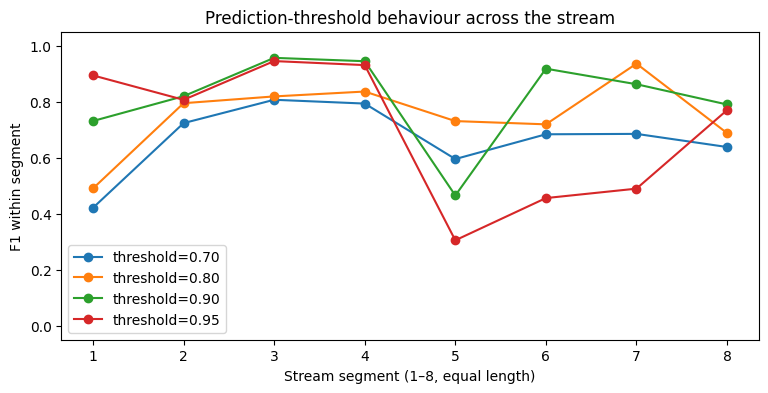

In [8]:
# Custom view: F1 over equal-length stream segments.
# This approximates the thesis's anomaly-equal bucket plots by dividing
# each run into equal-length sections and calculating F1 per section.

import glob
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline

N_BUCKETS = 8

run_globs = {
    "threshold=0.70": f"{OUTPUT_DIR}/{CASE_ID}_suite_resolved/Group/LSTM/threshold_0_7/*_seed_*/trial_predictions.csv",
    "threshold=0.80": f"{OUTPUT_DIR}/{CASE_ID}_suite_resolved/Group/LSTM/threshold_0_8/*_seed_*/trial_predictions.csv",
    "threshold=0.90": f"{OUTPUT_DIR}/{CASE_ID}_suite_resolved/Group/LSTM/threshold_0_9/*_seed_*/trial_predictions.csv",
    "threshold=0.95": f"{OUTPUT_DIR}/{CASE_ID}_suite_resolved/Group/LSTM/threshold_0_95/*_seed_*/trial_predictions.csv",
}

runs = {}
for label, pattern in run_globs.items():
    matches = sorted(glob.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"No prediction file found for {label}. Expected pattern:\n{pattern}")
    runs[label] = matches[0]


def bucket_f1(csv_path, n_buckets):
    df = pd.read_csv(
        csv_path, skiprows=1, header=None,
        names=["ts_start", "ts_end", "step", "confusion", "label",
               "final_pred", "trained", "final_conf", "metrics"],
    )
    df["bucket"] = pd.cut(df["step"], n_buckets, labels=False)
    output = [float("nan")] * n_buckets
    for bucket, group in df.groupby("bucket"):
        tp = (group["confusion"] == "TP").sum()
        fp = (group["confusion"] == "FP").sum()
        fn = (group["confusion"] == "FN").sum()
        precision = tp / (tp + fp) if (tp + fp) else float("nan")
        recall = tp / (tp + fn) if (tp + fn) else float("nan")
        if precision == precision and recall == recall and (precision + recall) > 0:
            f1 = 2 * precision * recall / (precision + recall)
        else:
            f1 = float("nan")
        output[int(bucket)] = f1
    return output


fig, ax = plt.subplots(figsize=(9, 4))
for label, path in runs.items():
    values = bucket_f1(path, N_BUCKETS)
    ax.plot(range(1, N_BUCKETS + 1), values, marker="o", label=label)

ax.set_xlabel("Stream segment (1–8, equal length)")
ax.set_ylabel("F1 within segment")
ax.set_title("Prediction-threshold behaviour across the stream")
ax.set_ylim(-0.05, 1.05)
ax.legend()
# display(fig) renders the Figure via IPython's own PNG hook, independent of
# matplotlib's backend — works the same whether MPLBACKEND=Agg (set earlier
# for headless/Colab runs) or an interactive backend is active, unlike
# plt.show() which is a no-op under Agg.
display(fig)
plt.close(fig)

#### The plots can indicate, among other things:

1. Whether the lowest threshold (0.70) over-predicts anomalies early in the stream, before adaptive score calibration stabilises.
2. Whether the highest threshold (0.95) loses recall evenly across the stream, or in specific stretches.
3. Whether the precision/recall trade-off is stable across the stream or concentrated at particular points.

### Main takeaway

Prediction-threshold selection is not only a static precision–recall trade-off measured once over the whole stream. In an online VAE, model updates and adaptive score calibration change the distribution seen during the stream, so a threshold that looks reasonable in the aggregate metrics can still be poorly calibrated during particular periods. This is why the thesis evaluates threshold behaviour over time in addition to reporting aggregate F1.

## Scope of this testcase

This notebook is a compact demonstration, not a full reproduction of every threshold experiment reported in the thesis. With `DATA_SOURCE = "full_split_files"` (the default) it runs on the full-scale group-anomaly data. With `DATA_SOURCE = "mini_50pct"` / `"mini_28pct"` a shorter ERA5 interval is used instead — useful for a quick check, but see `case01_clean_baseline.ipynb` for why it can give different results than the full-scale data.

The eight stream sections used above are an explanatory approximation of the thesis's bucket-based temporal analysis. Exact metric values and the exact position of performance changes may therefore differ from the full experiments (single seed, this repo's own port of the training code).

Conclusions should be based on the **direction and consistency of the precision/recall trade-off and the timing of threshold effects**, rather than exact numerical agreement with the thesis figures.

### Download all runs in this notebook

Off by default — see the cell below to enable it.

In [11]:
# Set to True and re-run this cell to download a zip of the run directory
# (OUTPUT_DIR), covering all runs in this notebook.
DOWNLOAD_RUN_DIR = False

import shutil

if not DOWNLOAD_RUN_DIR:
    print(
        "Run directory not downloaded (DOWNLOAD_RUN_DIR=False). "
        "To download it, set DOWNLOAD_RUN_DIR = True above and re-run this cell."
    )
else:
    from google.colab import files

    archive_path = shutil.make_archive(OUTPUT_DIR.rstrip("/").replace("/", "_"), "zip", OUTPUT_DIR)
    print(f"Zipped {OUTPUT_DIR} -> {archive_path}")
    files.download(archive_path)

Run directory not downloaded (DOWNLOAD_RUN_DIR=False). To download it, set DOWNLOAD_RUN_DIR = True above and re-run this cell.
